In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.tri as mtri
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import ascii
import pandas as pd
import networkx as nx
import scipy
import seaborn as sns
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import os

In [ ]:
filt_n1 = Table.read("/content/drive/MyDrive/DESI/data/LRG_NGC_data_filt1.ecsv").to_pandas()
filt_n2 = Table.read("/content/drive/MyDrive/DESI/data/LRG_NGC_data_filt2.ecsv").to_pandas()

In [ ]:
len(filt_n1)

728582

In [ ]:
n_random = 10
rand_ngc1 = {}
for i in range(n_random):
    rand_ngc1[i] = Table.read(f"/content/drive/MyDrive/DESI/rand/LRG_NGC_1_random_{i}_filt.fits").to_pandas()

In [ ]:
rand_ngc2 = {}
for i in range(n_random):
    rand_ngc2[i] = Table.read(f"/content/drive/MyDrive/DESI/rand/LRG_NGC_2_random_{i}_filt.fits").to_pandas()

# Visualization Random 0

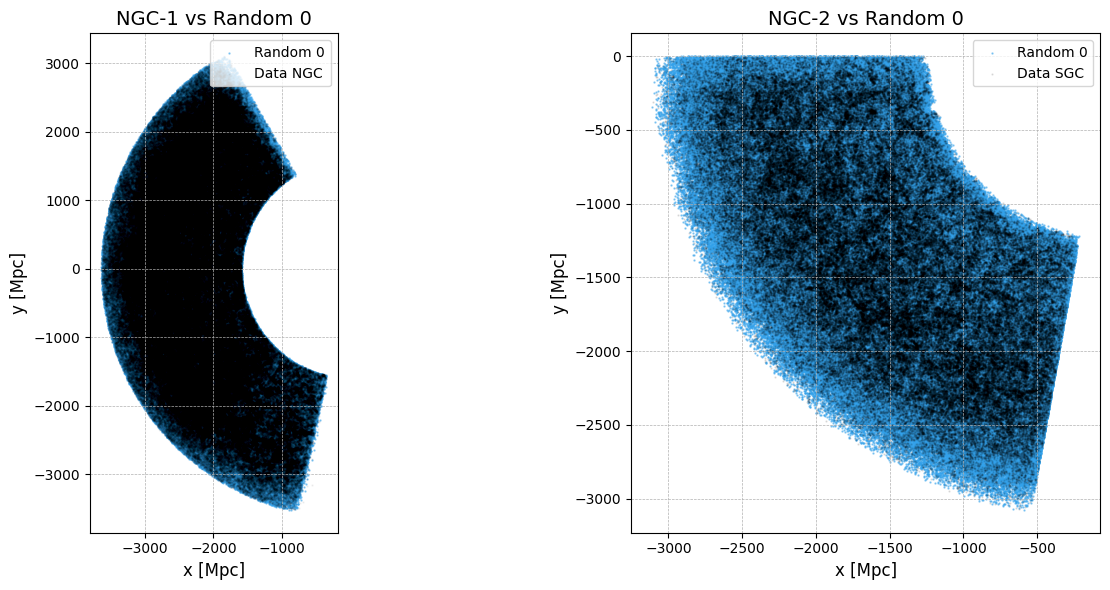

In [ ]:
i = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(rand_ngc1[i]['x'], rand_ngc1[i]['y'], c='#32A1EA', s=0.5, label=f'Random {i}',alpha=0.5)
axes[0].scatter(filt_n1['x'], filt_n1['y'], c='k', s=0.5, label='Data NGC',alpha=0.05)

axes[0].set_xlabel('x [Mpc]', size=12)
axes[0].set_ylabel('y [Mpc]', size=12)
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].set_title(f'NGC-1 vs Random {i}', fontsize=14)
axes[0].legend(loc='upper right')

axes[1].scatter(rand_ngc2[i]['x'], rand_ngc2[i]['y'], c='#32A1EA', s=0.5, label=f'Random {i}',alpha = 0.5)
axes[1].scatter(filt_n2['x'], filt_n2['y'], c='k', s=0.5, label='Data SGC',alpha=0.1)


axes[1].set_xlabel('x [Mpc]', size=12)
axes[1].set_ylabel('y [Mpc]', size=12)
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].set_title(f'NGC-2 vs Random {i}', fontsize=14)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

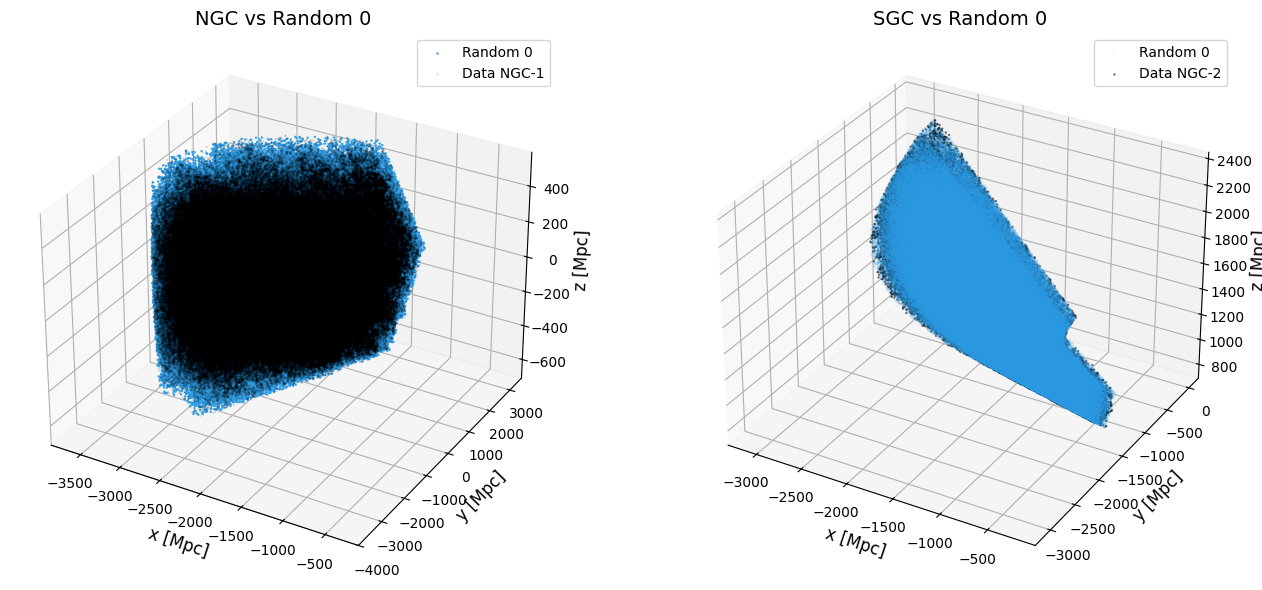

In [ ]:
i = 0

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(rand_ngc1[i]['x'], rand_ngc1[i]['y'], rand_ngc1[i]['z'], c='#32A1EA', s=0.5, label=f'Random {i}', alpha=1)
ax1.scatter(filt_n1['x'], filt_n1['y'], filt_n1['z'], c='k', s=0.5, label='Data NGC-1',alpha=0.1)

ax1.set_xlabel('x [Mpc]', size=12)
ax1.set_ylabel('y [Mpc]', size=12)
ax1.set_zlabel('z [Mpc]', size=12)
ax1.set_title(f'NGC vs Random {i}', fontsize=14)
ax1.legend(loc='upper right')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')

ax2.scatter(rand_ngc2[i]['x'], rand_ngc2[i]['y'], rand_ngc2[i]['z'], c='#32A1EA', s=0.5, label=f'Random {i}', alpha=0.1)
ax2.scatter(filt_n2['x'], filt_n2['y'], filt_n2['z'], c='k', s=0.5, label='Data NGC-2',alpha=0.5)

ax2.set_xlabel('x [Mpc]', size=12)
ax2.set_ylabel('y [Mpc]', size=12)
ax2.set_zlabel('z [Mpc]', size=12)
ax2.set_title(f'SGC vs Random {i}', fontsize=14)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Alignment

In [ ]:
def alignment(data):
    pca = PCA(n_components=3)

    coords = data[['x', 'y', 'z']].values
    coords_rotated = pca.fit_transform(coords)

    return(coords_rotated)

In [ ]:
filt_n1_al = alignment(filt_n1)
filt_n1['x_al'] = filt_n1_al[:,0]
filt_n1['y_al'] = filt_n1_al[:,1]
filt_n1['z_al'] = filt_n1_al[:,2]

filt_n2_al = alignment(filt_n2)
filt_n2['x_al'] = filt_n2_al[:,0]
filt_n2['y_al'] = filt_n2_al[:,1]
filt_n2['z_al'] = filt_n2_al[:,2]

In [ ]:
for key, table in rand_ngc1.items():
    coords = alignment(table)
    rand_ngc1[key]['x_al'] = coords[:,0]
    rand_ngc1[key]['y_al'] = coords[:,1]
    rand_ngc1[key]['z_al'] = coords[:,2]

In [ ]:
for key, table in rand_ngc2.items():
    coords = alignment(table)
    rand_ngc2[key]['x_al'] = coords[:,0]
    rand_ngc2[key]['y_al'] = coords[:,1]
    rand_ngc2[key]['z_al'] = coords[:,2]

In [ ]:
filt_n1

,TARGETID,x,y,z,type,x_al,y_al,z_al,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,class_8,class_9
0,39627546836338876,-2795.300802,1104.104570,-527.928694,data,1335.395843,-494.814528,-475.300662,b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet'
1,39627546840531340,-2960.713792,1167.454399,-554.322987,data,1417.908709,-653.121276,-489.510421,b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet'
2,39627546840533707,-2539.539691,992.642706,-475.920047,data,1194.077397,-250.904683,-442.445271,b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet'
3,39627546840534067,-2835.517143,1106.731781,-532.217253,data,1342.709671,-534.646514,-476.903437,b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet'
4,39627546840534396,-2269.660820,884.891431,-424.539424,data,1054.853272,7.390389,-411.057224,b'filament',b'sheet',b'filament',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
728577,39636777832553492,-877.435652,-2798.567870,410.258130,data,-2785.606220,1013.995505,252.770562,b'filament',b'sheet',b'sheet',b'filament',b'filament',b'filament',b'filament',b'filament',b'filament',b'sheet'
728578,39627697034366147,-2763.902149,394.006867,-185.203521,data,616.834348,-524.385409,-150.523648,b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'filament',b'sheet',b'sheet',b'sheet'
728579,39627762931077110,-1368.791192,1110.703909,-34.041194,data,1165.290193,950.872605,-75.362087,b'sheet',b'filament',b'filament',b'sheet',b'filament',b'filament',b'filament',b'sheet',b'sheet',b'sheet'
728580,39627829561787298,-1690.586821,887.768484,56.946983,data,977.960343,611.770068,31.635463,b'filament',b'sheet',b'sheet',b'sheet',b'sheet',b'sheet',b'filament',b'sheet',b'filament',b'sheet'


In [ ]:
rand_ngc1[0]

,TARGETID,x,y,z,type,x_al,y_al,z_al,class_0
0,327858307949660901,-2153.454540,2064.040374,315.936001,b'rand',2184.632091,306.183309,340.087208,b'filament'
1,327858067003673263,-3167.790274,972.848363,-228.983658,b'rand',1230.887216,-862.203740,-151.600537,b'filament'
2,327858279755548320,-1005.283763,-2741.295173,236.915487,b'rand',-2716.891537,881.904909,96.364297,b'sheet'
3,327858055830046125,-2095.441765,-1503.643105,-199.311707,b'rand',-1351.943130,-84.462557,-240.638725,b'sheet'
4,327858134552938296,-2054.899743,-2515.635038,-72.137249,b'rand',-2364.847454,-152.950504,-134.436549,b'filament'
...,...,...,...,...,...,...,...,...,...
728577,327858297191270024,-1511.379745,-949.624869,174.297361,b'rand',-878.084554,583.734906,100.855908,b'sheet'
728578,327858152961738223,-1095.895907,-2719.136327,-19.693923,b'rand',-2677.967434,777.355101,-152.842877,b'filament'
728579,327858157617416467,-2705.685921,696.450937,-14.939005,b'rand',898.075960,-421.846270,24.674954,b'sheet'
728580,327858230254373330,-2892.313983,244.402117,135.027450,b'rand',466.655886,-649.039123,179.362493,b'sheet'


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

data_dict = {'n': data_n, 's': data_s}
titles = {'n': 'Data NGC', 's': 'Data SGC'}

orientations = ['n', 's']

for idx, ori in enumerate(orientations):
    ax = axes[idx]
    data = data_dict[ori]

    # Histograma
    ax.hist(data['Z'], bins=20, color='#30C4C9', alpha=0.7)

    # Etiquetas y título
    ax.set_xlabel(r'Z')
    ax.set_ylabel('Counts')
    ax.set_title(titles[ori])
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.suptitle('Histograms of Data', fontsize=22, y=1)

plt.tight_layout(pad=1.0)
plt.show()

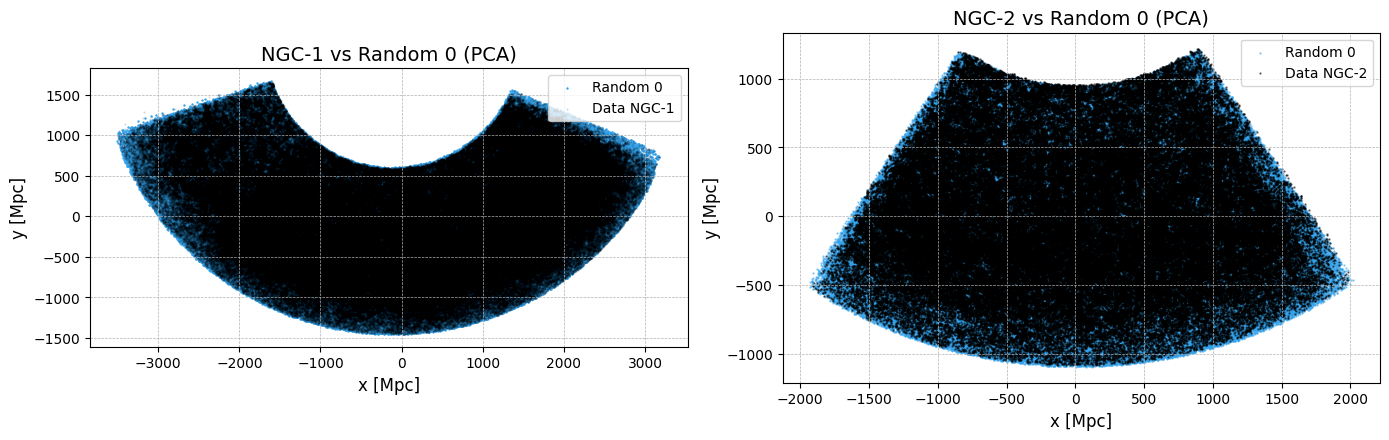

In [ ]:
i = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(rand_ngc1[i]['x_al'], rand_ngc1[i]['y_al'], c='#32A1EA', s=0.5, label=f'Random {i}',alpha=1)
axes[0].scatter(filt_n1['x_al'], filt_n1['y_al'], c='k', s=0.5, label='Data NGC-1',alpha=0.1)

axes[0].set_xlabel('x [Mpc]', size=12)
axes[0].set_ylabel('y [Mpc]', size=12)
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].set_title(f'NGC-1 vs Random {i} (PCA)', fontsize=14)
axes[0].legend(loc='upper right')

axes[1].scatter(rand_ngc2[i]['x_al'], rand_ngc2[i]['y_al'], c='#32A1EA', s=0.5, label=f'Random {i}',alpha=0.5)
axes[1].scatter(filt_n2['x_al'], filt_n2['y_al'], c='k', s=0.5, label='Data NGC-2',alpha=0.5)

axes[1].set_xlabel('x [Mpc]', size=12)
axes[1].set_ylabel('y [Mpc]', size=12)
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].set_title(f'NGC-2 vs Random {i} (PCA)', fontsize=14)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
rand_ngc1[0]

,TARGETID,x,y,z,type,x_al,y_al,z_al,class_0
0,327858307949660901,-2153.454540,2064.040374,315.936001,b'rand',2184.632091,306.183309,340.087208,b'filament'
1,327858067003673263,-3167.790274,972.848363,-228.983658,b'rand',1230.887216,-862.203740,-151.600537,b'filament'
2,327858279755548320,-1005.283763,-2741.295173,236.915487,b'rand',-2716.891537,881.904909,96.364297,b'sheet'
3,327858055830046125,-2095.441765,-1503.643105,-199.311707,b'rand',-1351.943130,-84.462557,-240.638725,b'sheet'
4,327858134552938296,-2054.899743,-2515.635038,-72.137249,b'rand',-2364.847454,-152.950504,-134.436549,b'filament'
...,...,...,...,...,...,...,...,...,...
728577,327858297191270024,-1511.379745,-949.624869,174.297361,b'rand',-878.084554,583.734906,100.855908,b'sheet'
728578,327858152961738223,-1095.895907,-2719.136327,-19.693923,b'rand',-2677.967434,777.355101,-152.842877,b'filament'
728579,327858157617416467,-2705.685921,696.450937,-14.939005,b'rand',898.075960,-421.846270,24.674954,b'sheet'
728580,327858230254373330,-2892.313983,244.402117,135.027450,b'rand',466.655886,-649.039123,179.362493,b'sheet'


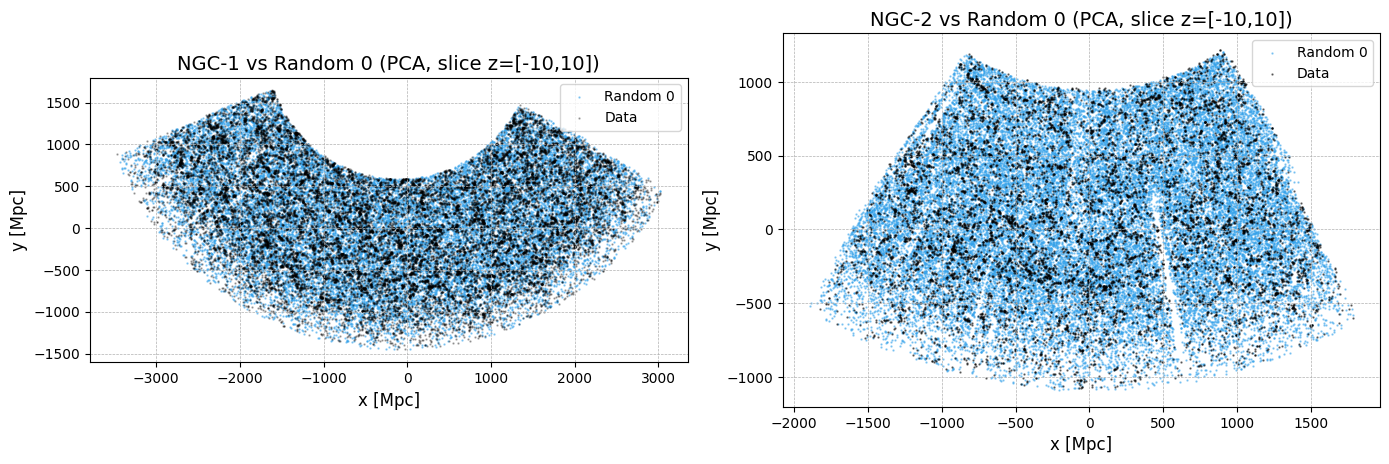

In [ ]:
i = 0

# Definir slice (ajusta el rango a lo que necesites)
zmin, zmax = -10, 10

slice_mask_rand1 = (rand_ngc1[i]['z_al'] > zmin) & (rand_ngc1[i]['z_al'] < zmax)
slice_mask_rand2 = (rand_ngc2[i]['z_al'] > zmin) & (rand_ngc2[i]['z_al'] < zmax)
slice_mask_data1 = (filt_n1['z_al'] > zmin) & (filt_n1['z_al'] < zmax)
slice_mask_data2 = (filt_n2['z_al'] > zmin) & (filt_n2['z_al'] < zmax)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- NGC-1 ---
axes[0].scatter(rand_ngc1[i].loc[slice_mask_rand1, 'x_al'],
                rand_ngc1[i].loc[slice_mask_rand1, 'y_al'],
                c='#32A1EA', s=0.5, label=f'Random {i}', alpha=0.5)
axes[0].scatter(filt_n1.loc[slice_mask_data1, 'x_al'],
                filt_n1.loc[slice_mask_data1, 'y_al'],
                c='k', s=0.5, label='Data', alpha=0.3)

axes[0].set_xlabel('x [Mpc]', size=12)
axes[0].set_ylabel('y [Mpc]', size=12)
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].set_title(f'NGC-1 vs Random {i} (PCA, slice z=[{zmin},{zmax}])', fontsize=14)
axes[0].legend(loc='upper right')

# --- NGC-2 ---
axes[1].scatter(rand_ngc2[i].loc[slice_mask_rand2, 'x_al'],
                rand_ngc2[i].loc[slice_mask_rand2, 'y_al'],
                c='#32A1EA', s=0.5, label=f'Random {i}', alpha=0.5)
axes[1].scatter(filt_n2.loc[slice_mask_data2, 'x_al'],
                filt_n2.loc[slice_mask_data2, 'y_al'],
                c='k', s=0.5, label='Data', alpha=0.5)

axes[1].set_xlabel('x [Mpc]', size=12)
axes[1].set_ylabel('y [Mpc]', size=12)
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].set_title(f'NGC-2 vs Random {i} (PCA, slice z=[{zmin},{zmax}])', fontsize=14)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


# Classes

In [ ]:
class_ngc1 = {}
for i in range(n_random):
    table = Table.read(f"/content/drive/MyDrive/DESI/classification/LRG_NGC_1_random_{i}_filt.fits").to_pandas()
    class_ngc1[i] = dict(zip(table['TARGETID'], table[f'class_{i}']))

class_ngc2 = {}
for i in range(n_random):
    table = Table.read(f"/content/drive/MyDrive/DESI/classification/LRG_NGC_2_random_{i}_filt.fits").to_pandas()
    class_ngc2[i] = dict(zip(table['TARGETID'], table[f'class_{i}']))

In [ ]:
for i in range(n_random):
    rand_ngc1[i][f'class_{i}'] = rand_ngc1[i]['TARGETID'].map(class_ngc1[i])
    rand_ngc2[i][f'class_{i}'] = rand_ngc2[i]['TARGETID'].map(class_ngc2[i])
    filt_n1[f'class_{i}'] = filt_n1['TARGETID'].map(class_ngc1[i])
    filt_n2[f'class_{i}'] = filt_n2['TARGETID'].map(class_ngc2[i])

In [ ]:
def mask_classification(data, rand):
    data = data.copy()
    for col in data.columns:
        if col.startswith('class_'):
            data[col] = data[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
    col = f'class_{rand}'
    cls = data[col]

    return {
        'void':     data[cls == 'void'].reset_index(drop=True),
        'sheet':    data[cls == 'sheet'].reset_index(drop=True),
        'filament': data[cls == 'filament'].reset_index(drop=True),
        'knot':     data[cls == 'knot'].reset_index(drop=True)
    }

In [ ]:
def plot_2d(number,key, real, rand):
  mask_real = mask_classification(real, key)
  mask_rand = mask_classification(rand, key)

  titles = ['void', 'sheet', 'filament', 'knot']
  fig, axes = plt.subplots(2, 2, figsize=(18, 10))
  ax = axes.ravel()

  for i, title in enumerate(titles):
      coords_real = mask_real[title]
      coords_rand = mask_rand[title]

      ax[i].scatter(coords_rand['x_al'], coords_rand['y_al'],c='#32A1EA', s=1, label='Random', alpha=0.6)
      ax[i].scatter(coords_real['x_al'], coords_real['y_al'],c='k', s=1, label='Real', alpha=0.2)

      ax[i].set_title(title, fontsize=14)
      ax[i].set_xlabel('x [Mpc]', size=12)
      ax[i].set_ylabel('y [Mpc]', size=12)
      ax[i].grid(True, linestyle='--', linewidth=0.5)
      ax[i].legend(loc='upper right')
      #ax[i].set_aspect('equal', adjustable='box')


  fig.suptitle(f'Structures by Classification (NGC-{number} vs Random {key})',
              fontsize=16, y=1)
  #plt.subplots_adjust(wspace=0.05, hspace=0.25)
  plt.tight_layout()
  plt.savefig(f'NGC_{number}_random_{key}', dpi=300, bbox_inches='tight')
  plt.show()

In [ ]:
def plot_2d_filt(number, key, real, rand, pc3_slice):
    class_real = mask_classification(real, key)
    class_rand = mask_classification(rand, key)

    titles = ['void', 'sheet', 'filament', 'knot']
    fig, axes = plt.subplots(2, 2, figsize=(18, 8))
    ax = axes.ravel()

    for i, title in enumerate(titles):
        coords_real = class_real[title]
        coords_rand = class_rand[title]

        mask_real_z = (coords_real['z_al'] >= pc3_slice[0]) & (coords_real['z_al'] <= pc3_slice[1])
        mask_rand_z = (coords_rand['z_al'] >= pc3_slice[0]) & (coords_rand['z_al'] <= pc3_slice[1])

        coords_real_slice = coords_real[mask_real_z]
        coords_rand_slice = coords_rand[mask_rand_z]

        ax[i].scatter(coords_rand_slice['x_al'], coords_rand_slice['y_al'],c='#32A1EA', s=1, label='Random', alpha=1)
        ax[i].scatter(coords_real_slice['x_al'], coords_real_slice['y_al'],c='k', s=1, label='Real', alpha=1)

        ax[i].set_title(title, fontsize=14)
        ax[i].set_xlabel('x [Mpc]', size=12)
        ax[i].set_ylabel('y [Mpc]', size=12)
        ax[i].grid(True, linestyle='--', linewidth=0.5)
        ax[i].legend(loc='upper right')

    fig.suptitle(f'Structures by Classification (NGC-{number} vs Random {key}) {pc3_slice}',
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_2d_1plot_real(number, key, real, pc3_slice):
    class_real = mask_classification(real, key)

    titles = ['void', 'sheet', 'filament', 'knot']
    colors = {
        'void': '#ec6363',
        'sheet': '#36cecc',
        'filament': '#176585',
        'knot': '#fecd23'
    }

    fig, ax = plt.subplots(figsize=(9, 4))

    for title in titles:
        coords_real = class_real[title]

        mask_real_z = (coords_real['z_al'] >= pc3_slice[0]) & (coords_real['z_al'] <= pc3_slice[1])

        coords_real_slice = coords_real[mask_real_z]

        ax.scatter(coords_real_slice['x_al'], coords_real_slice['y_al'], c=colors[title], s=14, alpha=0.8, marker='o',
                   linewidths=0.2, label=f'{title}')

    ax.set_title(f'Structures by Classification (NGC-{number}) Real data {pc3_slice}', fontsize=16)
    ax.set_xlabel('x [Mpc]', size=12)
    ax.set_ylabel('y [Mpc]', size=12)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend(loc='upper right', markerscale=4, fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_2d_1plot_rand(number, key, real, rand, pc3_slice):
    class_real = mask_classification(real, key)
    class_rand = mask_classification(rand, key)

    titles = ['void', 'sheet', 'filament', 'knot']
    colors = {
        'void': '#ec6363',
        'sheet': '#36cecc',
        'filament': '#176585',
        'knot': '#fecd23'
    }

    fig, ax = plt.subplots(figsize=(9, 4))

    for title in titles:
        coords_real = class_real[title]
        mask_real_z = (coords_real['z_al'] >= pc3_slice[0]) & (coords_real['z_al'] <= pc3_slice[1])
        coords_real_slice = coords_real[mask_real_z]

        coords_rand = class_rand[title]
        mask_rand_z = (coords_rand['z_al'] >= pc3_slice[0]) & (coords_rand['z_al'] <= pc3_slice[1])
        coords_rand_slice = coords_rand[mask_rand_z]

        ax.scatter(coords_rand_slice['x_al'], coords_rand_slice['y_al'],c=colors[title], s=14, alpha=0.3, marker='o',
                   linewidths=0)

        ax.scatter(coords_real_slice['x_al'], coords_real_slice['y_al'],c=colors[title], s=14, alpha=0.9, marker='o',
                   linewidths=0.2, label=f'{title}')

    ax.set_title(f'Structures by Classification (NGC-{number} vs Random {key}) {pc3_slice}', fontsize=16)
    ax.set_xlabel('x [Mpc]', size=12)
    ax.set_ylabel('y [Mpc]', size=12)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend(loc='upper right', markerscale=3, fontsize=8)
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

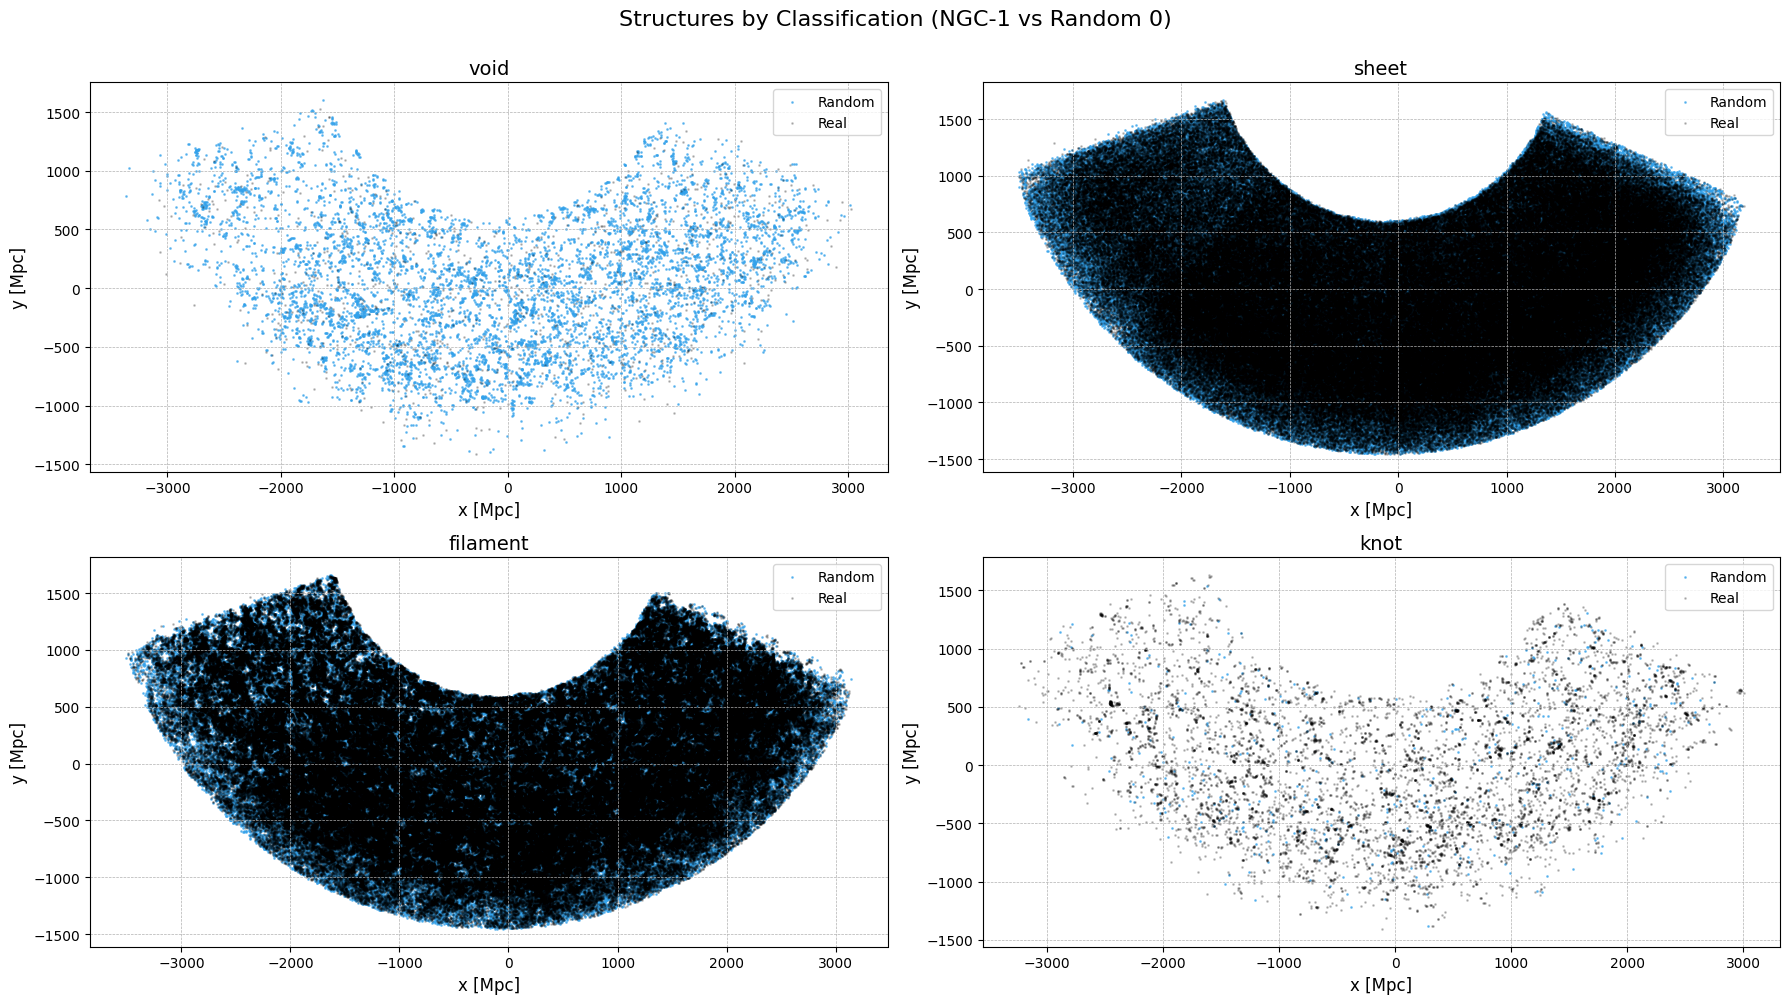

In [ ]:
random = 0
number_data = 1
plot_2d(number_data,random,filt_n1,rand_ngc1[random])

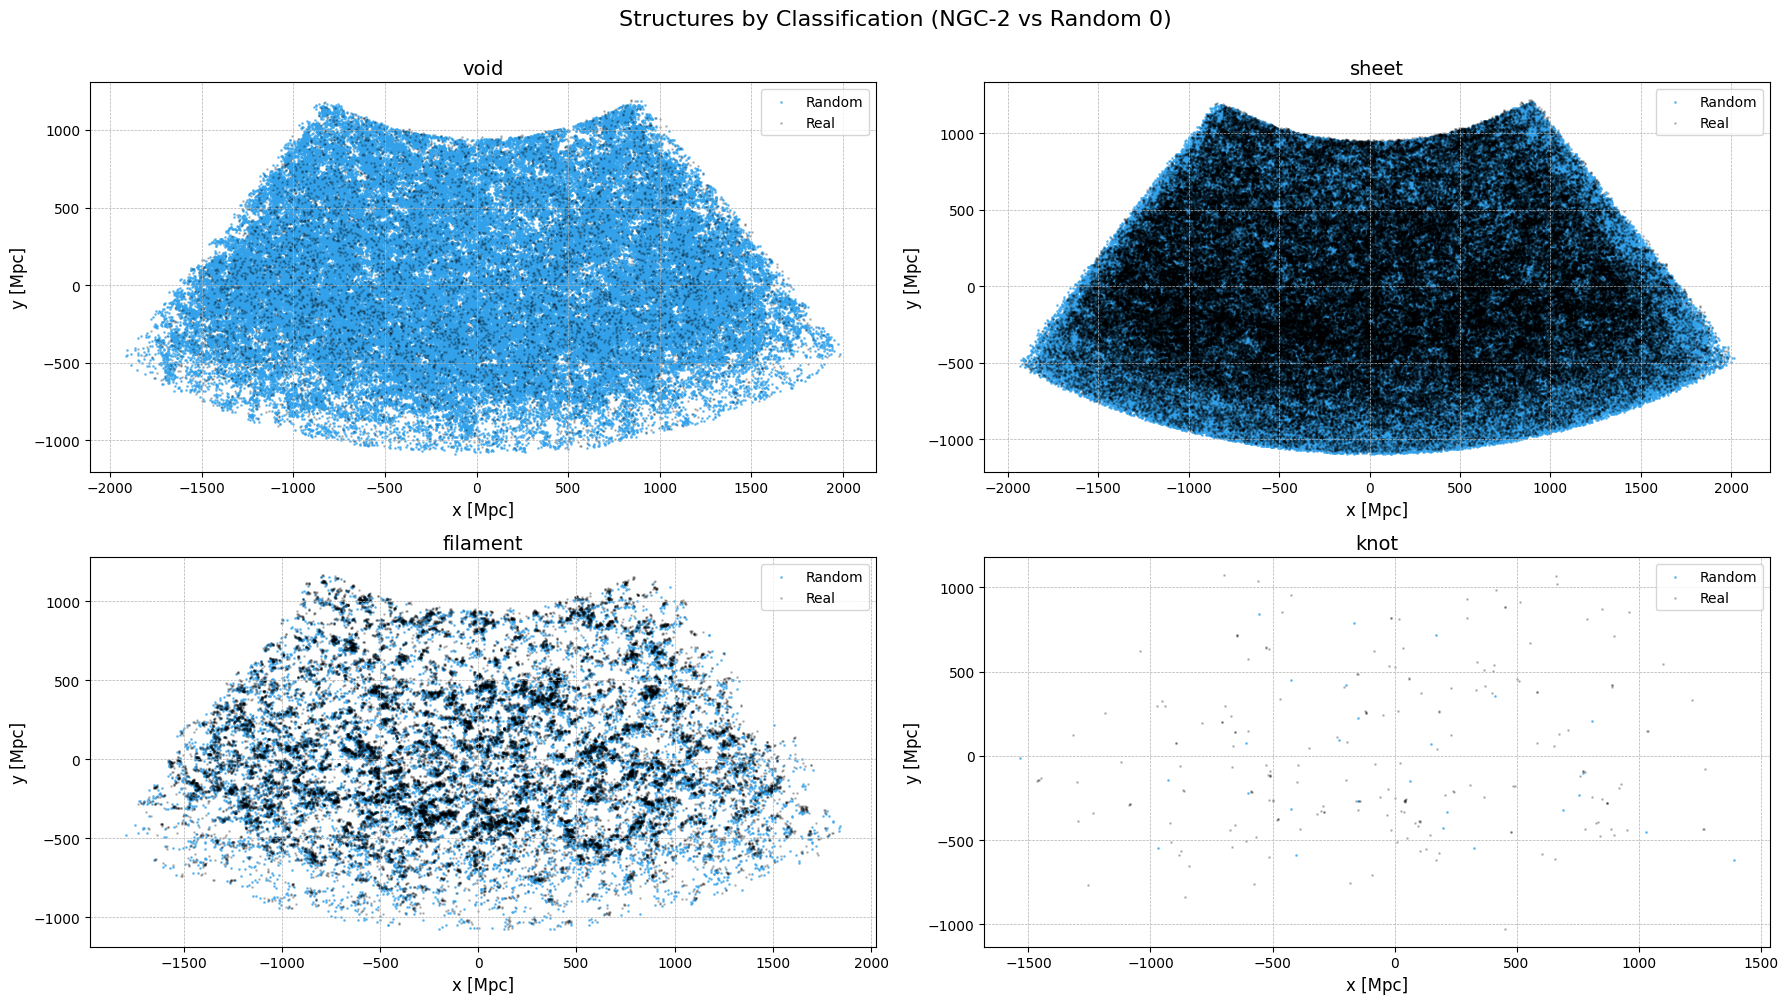

In [ ]:
random = 0
number_data = 2
plot_2d(number_data,random,filt_n2,rand_ngc2[random])

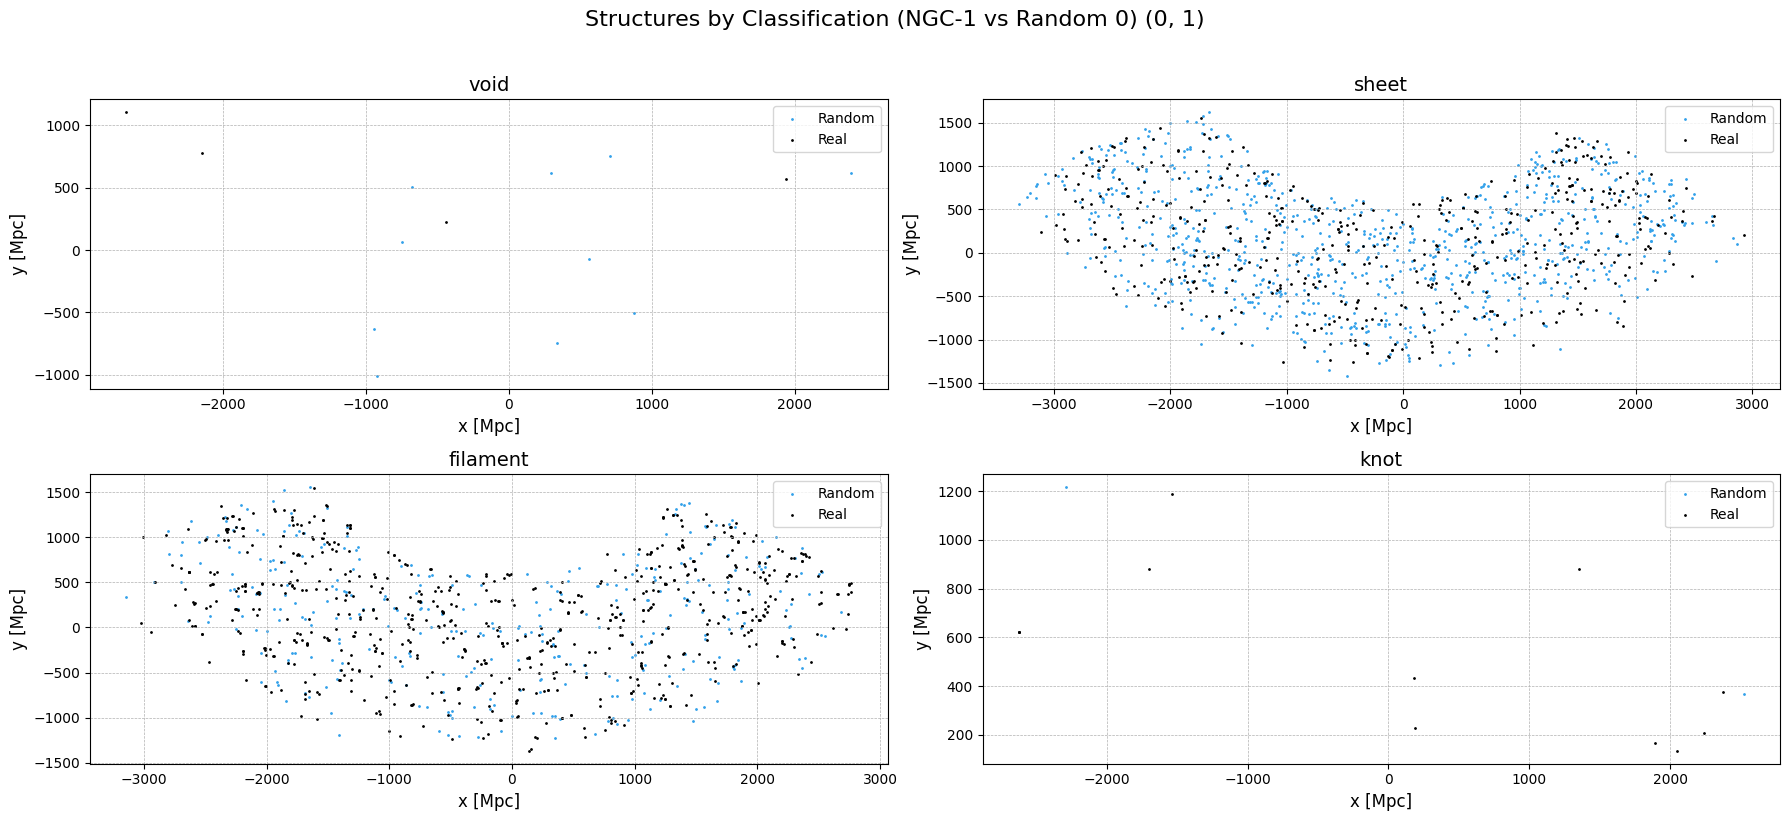

In [ ]:
random = 0
number_data = 1
plot_2d_filt(number_data,random,filt_n1,rand_ngc1[random],pc3_slice = (0,1))

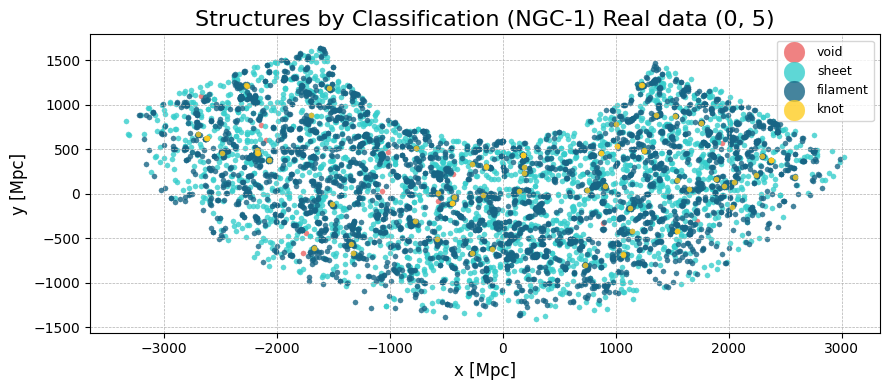

In [ ]:
random = 0
number_data = 1
plot_2d_1plot_real(number_data,random,filt_n1,pc3_slice = (0,5))

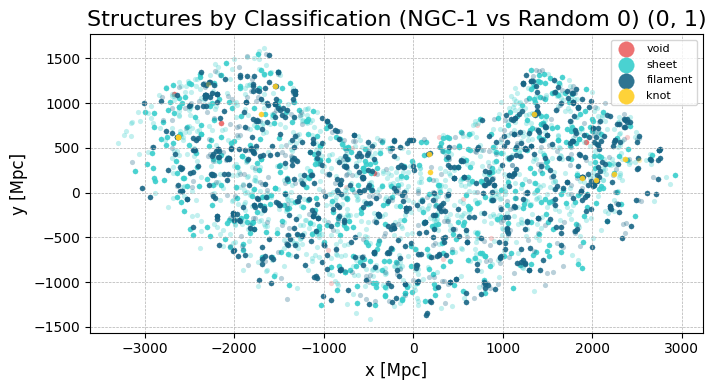

In [ ]:
random = 0
number_data = 1
plot_2d_1plot_rand(number_data,random,filt_n1,rand_ngc1[random],pc3_slice = (0,1))

In [ ]:
def plot_rand(number, key, rand,title):
    mask_rand = mask_classification(rand, key)

    fig, ax = plt.subplots(figsize=(9, 4))

    coords_rand = mask_rand[title]
    ax.scatter(coords_rand['x_al'], coords_rand['y_al'],
               c='#32A1EA', s=0.5, label='Random', alpha=0.6)

    ax.set_xlabel('x [Mpc]', size=12)
    ax.set_ylabel('y [Mpc]', size=12)
    ax.grid(True, linestyle='--', linewidth=0.5)
    #ax.legend(loc='upper right')
    ax.set_aspect('equal', adjustable='box')

    fig.suptitle(f'LRG', fontsize=16,y=0.93)
    plt.xlim(0,200)
    plt.ylim(0,200)
    plt.tight_layout()
    plt.savefig(f'NGC_{number}_{title}_random_{key}', dpi=300, bbox_inches='tight')
    plt.show()

def plot_data(number, key, data,title):
    mask_data = mask_classification(data, key)

    fig, ax = plt.subplots(figsize=(9, 4))

    coords_data = mask_data[title]
    ax.scatter(coords_data['x_al'], coords_data['y_al'],
               c='k', s=0.5, label='Data', alpha=0.6)

    ax.set_xlabel('x [Mpc]', size=12)
    ax.set_ylabel('y [Mpc]', size=12)
    ax.grid(True, linestyle='--', linewidth=0.5)
    #ax.legend(loc='upper right')
    ax.set_aspect('equal', adjustable='box')
    plt.xlim(0,200)
    plt.ylim(0,200)

    fig.suptitle(f'LRG', fontsize=16,y=0.93)
    plt.tight_layout()
    plt.savefig(f'NGC_{number}_{title}_random_{key}', dpi=300, bbox_inches='tight')
    plt.show()

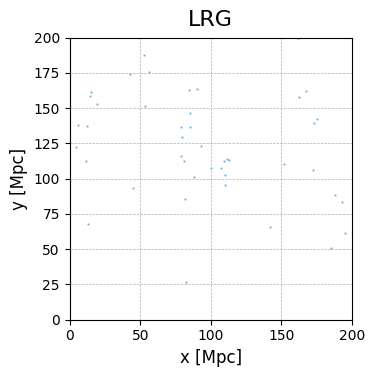

In [ ]:
plot_rand(1,0,rand_ngc1[0],'void')

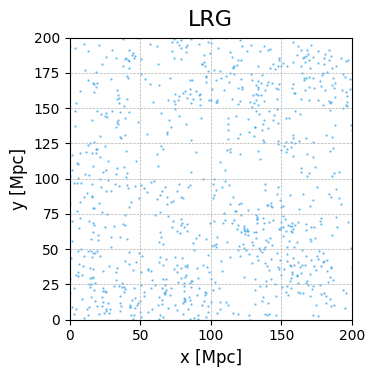

In [ ]:
plot_rand(2,0,rand_ngc2[0],'void')

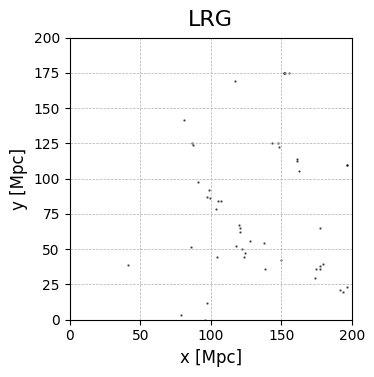

In [ ]:
plot_data(1, 0, filt_n1,'knot')

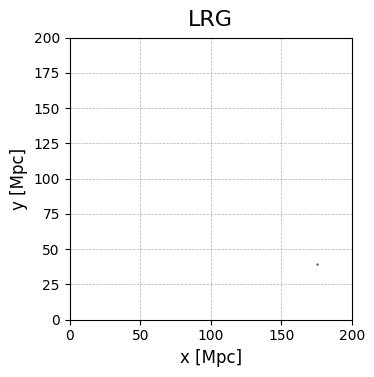

In [ ]:
plot_data(2, 0, filt_n2,'knot')

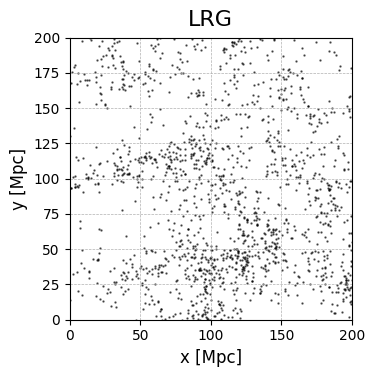

In [ ]:
plot_data(1, 0, filt_n1,'filament')

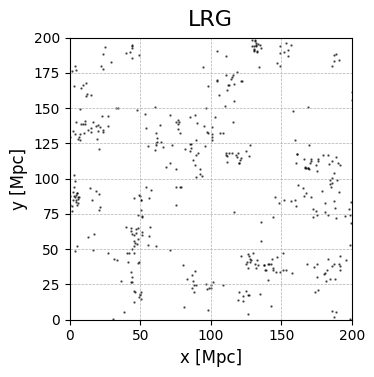

In [ ]:
plot_data(2, 0, filt_n2,'filament')

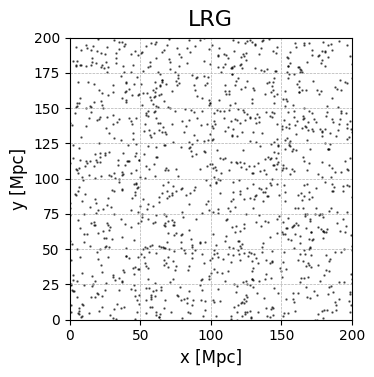

In [ ]:
plot_data(1, 0, filt_n1,'sheet')

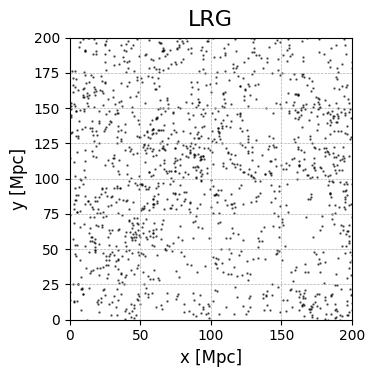

In [ ]:
plot_data(2, 0, filt_n2,'sheet')